# 🏘️ Housing Price Prediction Analysis

## Multiple Linear Regression Model for Real Estate Valuation

> This project demonstrates a complete machine learning workflow: from data exploration and cleaning to model training, evaluation, and comprehensive visualization of results.

---

### 📊 Project Objectives

- ✅ Explore and understand the housing dataset structure
- ✅ Clean data by handling duplicates, missing values, and outliers
- ✅ Build a multiple linear regression model
- ✅ Evaluate model performance using R² and other metrics
- ✅ Visualize results with professional graphs
- ✅ Generate comprehensive analysis report

### 📈 Dataset Features

| Feature | Description |
|---------|-------------|
| **RM** | Average number of rooms per dwelling |
| **LSTAT** | Percentage of lower status population |
| **PTRATIO** | Pupil-teacher ratio by town |
| **MEDV** | Median value of homes (Target Variable) |

---

## 📑 Table of Contents

1. [Libraries & Setup](#setup)
2. [Data Loading & Preview](#loading)
3. [Data Exploration](#exploration)
4. [Data Cleaning](#cleaning)
5. [Feature Preparation](#features)
6. [Train-Test Split](#split)
7. [Model Training](#training)
8. [R² Analysis & Evaluation](#evaluation)
9. [Visualizations](#visualizations)
10. [Summary Report](#summary)

In [23]:
import pandas as    pd

---

## <a id="setup"></a>1️⃣ Libraries & Setup

### Required Packages
Install and import all essential libraries for data analysis, machine learning, and visualization.

In [24]:
pd.read_csv(r"C:\Users\Admin\Desktop\Sai work\Sem 4\Python\archive (1)\housing.csv")

,RM,LSTAT,PTRATIO,MEDV
0,6.575,4.98,15.3,504000.0
1,6.421,9.14,17.8,453600.0
2,7.185,4.03,17.8,728700.0
3,6.998,2.94,18.7,701400.0
4,7.147,5.33,18.7,760200.0
...,...,...,...,...
484,6.593,9.67,21.0,470400.0
485,6.120,9.08,21.0,432600.0
486,6.976,5.64,21.0,501900.0
487,6.794,6.48,21.0,462000.0


### Load Full Dataset

Preview the housing dataset directly from CSV file.

In [25]:
# Import all required libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import seaborn as sns

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("=" * 70)
print("HOUSING DATASET - MULTIPLE LINEAR REGRESSION ANALYSIS")
print("=" * 70)

HOUSING DATASET - MULTIPLE LINEAR REGRESSION ANALYSIS


### Complete Library Configuration

Configure all necessary imports and visualization settings for the analysis.

In [26]:
# Step 1: Data Exploration
print("\n" + "=" * 70)
print("STEP 1: DATA EXPLORATION")
print("=" * 70)

# Store original dataset
df = pd.read_csv(r"C:\Users\Admin\Desktop\Sai work\Sem 4\Python\archive (1)\housing.csv")

print(f"\n📊 Dataset Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n📋 First Few Rows:")
print(df.head(10))

print("\n📈 Dataset Info:")
print(df.info())

print("\n📊 Statistical Summary:")
print(df.describe())

print("\n🔍 Missing Values:")
missing = df.isnull().sum()
print(missing)
print(f"Total missing values: {missing.sum()}")


STEP 1: DATA EXPLORATION

📊 Dataset Shape: (489, 4)
Rows: 489, Columns: 4

📋 First Few Rows:
      RM  LSTAT  PTRATIO      MEDV
0  6.575   4.98     15.3  504000.0
1  6.421   9.14     17.8  453600.0
2  7.185   4.03     17.8  728700.0
3  6.998   2.94     18.7  701400.0
4  7.147   5.33     18.7  760200.0
5  6.430   5.21     18.7  602700.0
6  6.012  12.43     15.2  480900.0
7  6.172  19.15     15.2  569100.0
8  5.631  29.93     15.2  346500.0
9  6.004  17.10     15.2  396900.0

📈 Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 489 entries, 0 to 488
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   RM       489 non-null    float64
 1   LSTAT    489 non-null    float64
 2   PTRATIO  489 non-null    float64
 3   MEDV     489 non-null    float64
dtypes: float64(4)
memory usage: 15.4 KB
None

📊 Statistical Summary:
               RM       LSTAT     PTRATIO          MEDV
count  489.000000  489.000000  489.000000  4.890000e+02
m

---

## <a id="exploration"></a>2️⃣ Data Exploration 🔍

### Understanding the Dataset

This section analyzes the structure, dimensions, data types, and statistical properties of the dataset.

**Key Activities:**
- 📏 Check dataset shape and dimensions
- 📋 Display first few rows
- 📊 Generate statistical summaries
- 🔎 Identify missing values
- 📈 Analyze data distributions

In [27]:
# Step 2: Data Cleaning
print("\n" + "=" * 70)
print("STEP 2: DATA CLEANING")
print("=" * 70)

df_clean = df.copy()
initial_rows = len(df_clean)

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()
duplicates_removed = initial_rows - len(df_clean)
print(f"\n🗑️  Duplicates removed: {duplicates_removed}")

# Remove rows with missing values
df_clean = df_clean.dropna()
print(f"📉 Rows after removing null values: {len(df_clean)}")

# Check for outliers using IQR method
print(f"\n🎯 Outlier Detection (IQR Method):")
Q1 = df_clean.quantile(0.25)
Q3 = df_clean.quantile(0.75)
IQR = Q3 - Q1

outliers_mask = ((df_clean < (Q1 - 1.5 * IQR)) | (df_clean > (Q3 + 1.5 * IQR))).any(axis=1)
outliers_count = outliers_mask.sum()
print(f"Outliers detected: {outliers_count}")

# Remove outliers
df_clean = df_clean[~outliers_mask]
print(f"Rows after removing outliers: {len(df_clean)}")

print(f"\n✅ Data Cleaning Summary:")
print(f"   Original rows: {initial_rows}")
print(f"   Final rows: {len(df_clean)}")
print(f"   Rows removed: {initial_rows - len(df_clean)} ({(initial_rows - len(df_clean))/initial_rows*100:.1f}%)")

print(f"\n📊 Cleaned Dataset Statistics:")
print(df_clean.describe())


STEP 2: DATA CLEANING

🗑️  Duplicates removed: 0
📉 Rows after removing null values: 489

🎯 Outlier Detection (IQR Method):
Outliers detected: 45
Rows after removing outliers: 444

✅ Data Cleaning Summary:
   Original rows: 489
   Final rows: 444
   Rows removed: 45 (9.2%)

📊 Cleaned Dataset Statistics:
               RM       LSTAT     PTRATIO           MEDV
count  444.000000  444.000000  444.000000     444.000000
mean     6.192554   13.046802   18.705180  431559.459459
std      0.476993    6.439961    1.909285  130826.329405
min      4.880000    1.980000   14.700000  105000.000000
25%      5.883000    7.790000   17.600000  348075.000000
50%      6.163500   12.135000   19.100000  430500.000000
75%      6.484250   17.152500   20.200000  501900.000000
max      7.420000   30.810000   22.000000  764400.000000


---

## <a id="cleaning"></a>3️⃣ Data Cleaning 🧹

### Preparing Data for Analysis

Clean and preprocess the dataset to ensure data quality for modeling.

**Cleaning Tasks:**
- 🗑️ Remove duplicate rows
- ❌ Handle missing/null values
- 🎯 Detect and remove outliers using IQR (Interquartile Range) method
- ✅ Validate cleaned dataset statistics

**Formula for Outlier Detection:**
- Lower Bound = Q₁ - 1.5 × IQR
- Upper Bound = Q₃ + 1.5 × IQR
- (where IQR = Q₃ - Q₁)

In [28]:
# Step 3: Prepare Features and Target Variable
print("\n" + "=" * 70)
print("STEP 3: PREPARING DATA FOR MODELING")
print("=" * 70)

# Select features (X) and target (y)
# For housing dataset: Use RM, LSTAT, PTRATIO as features, MEDV as target
X = df_clean[['RM', 'LSTAT', 'PTRATIO']]  # Features
y = df_clean['MEDV']  # Target variable

print(f"\n🎯 Features (X):")
print(f"   Shape: {X.shape}")
print(f"   Columns: {list(X.columns)}")
print(f"   - RM: Average number of rooms per dwelling")
print(f"   - LSTAT: % of lower status of the population")
print(f"   - PTRATIO: Pupil-teacher ratio by town")

print(f"\n🏠 Target (y):")
print(f"   Shape: {y.shape}")
print(f"   Column: {y.name}")
print(f"   Description: Median value of homes")

print(f"\n📊 Feature Statistics:")
print(X.describe())

print(f"\n🎯 Target Statistics:")
print(y.describe())


STEP 3: PREPARING DATA FOR MODELING

🎯 Features (X):
   Shape: (444, 3)
   Columns: ['RM', 'LSTAT', 'PTRATIO']
   - RM: Average number of rooms per dwelling
   - LSTAT: % of lower status of the population
   - PTRATIO: Pupil-teacher ratio by town

🏠 Target (y):
   Shape: (444,)
   Column: MEDV
   Description: Median value of homes

📊 Feature Statistics:
               RM       LSTAT     PTRATIO
count  444.000000  444.000000  444.000000
mean     6.192554   13.046802   18.705180
std      0.476993    6.439961    1.909285
min      4.880000    1.980000   14.700000
25%      5.883000    7.790000   17.600000
50%      6.163500   12.135000   19.100000
75%      6.484250   17.152500   20.200000
max      7.420000   30.810000   22.000000

🎯 Target Statistics:
count       444.000000
mean     431559.459459
std      130826.329405
min      105000.000000
25%      348075.000000
50%      430500.000000
75%      501900.000000
max      764400.000000
Name: MEDV, dtype: float64


---

## <a id="features"></a>4️⃣ Feature Preparation 🎯

### Selecting Features and Target Variable

Select the input features (X) and output target (y) for the model.

**Feature Variables (X):**
- **RM**: Average number of rooms per dwelling
  - Impact: More rooms typically increases house value
  
- **LSTAT**: % of lower status population
  - Impact: Higher percentage may decrease house value
  
- **PTRATIO**: Pupil-teacher ratio by town
  - Impact: Better ratios (lower values) indicate better schools

**Target Variable (y):**
- **MEDV**: Median value of homes in $1000s
  - This is what we want to predict

In [29]:
# Step 4: Train-Test Split
print("\n" + "=" * 70)
print("STEP 4: TRAIN-TEST SPLIT")
print("=" * 70)

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% for testing
    random_state=42     # For reproducibility
)

total_samples = len(X)
train_pct = len(X_train) / total_samples * 100
test_pct = len(X_test) / total_samples * 100

print(f"\n📊 Split Ratio:")
print(f"   Total samples: {total_samples}")
print(f"   Training set: {len(X_train)} samples ({train_pct:.1f}%)")
print(f"   Testing set: {len(X_test)} samples ({test_pct:.1f}%)")

print(f"\n📐 Data Shapes:")
print(f"   X_train: {X_train.shape}")
print(f"   X_test: {X_test.shape}")
print(f"   y_train: {y_train.shape}")
print(f"   y_test: {y_test.shape}")

print(f"\n📈 Training Set Statistics:")
print(f"   Features mean: {X_train.mean().values}")
print(f"   Target mean: {y_train.mean():.2f}")

print(f"\n📈 Testing Set Statistics:")
print(f"   Features mean: {X_test.mean().values}")
print(f"   Target mean: {y_test.mean():.2f}")


STEP 4: TRAIN-TEST SPLIT

📊 Split Ratio:
   Total samples: 444
   Training set: 355 samples (80.0%)
   Testing set: 89 samples (20.0%)

📐 Data Shapes:
   X_train: (355, 3)
   X_test: (89, 3)
   y_train: (355,)
   y_test: (89,)

📈 Training Set Statistics:
   Features mean: [ 6.20820282 13.15174648 18.6743662 ]
   Target mean: 432783.38

📈 Testing Set Statistics:
   Features mean: [ 6.13013483 12.62820225 18.82808989]
   Target mean: 426677.53


---

## <a id="split"></a>5️⃣ Train-Test Split ✂️

### Dividing Data for Model Evaluation

Split the dataset into separate training and testing subsets to properly evaluate model performance.

**Why Split the Data?**
- 🎓 **Training Set (80%)**: Used to train the model
- 🧪 **Testing Set (20%)**: Used to evaluate on unseen data
- 📊 Helps detect overfitting and underfitting
- ✅ Ensures reliable performance estimation

**Benefits:**
- Prevents model from memorizing the training data
- Provides unbiased estimate of model performance
- Detects if model generalizes well to new data

In [30]:
# Step 5: Multiple Linear Regression Model
print("\n" + "=" * 70)
print("STEP 5: MULTIPLE LINEAR REGRESSION MODEL")
print("=" * 70)

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

print(f"\n✅ Model trained successfully!")

print(f"\n📐 Model Equation:")
print(f"   MEDV = {model.intercept_:.2f}", end="")
for feature, coeff in zip(X.columns, model.coef_):
    sign = "+" if coeff >= 0 else ""
    print(f" {sign} {coeff:.6f} * {feature}", end="")
print()

print(f"\n📊 Model Coefficients:")
for feature, coeff in zip(X.columns, model.coef_):
    print(f"   {feature:<12} = {coeff:>12.6f}")
print(f"   {'Intercept':<12} = {model.intercept_:>12.2f}")

# Make predictions on both training and testing sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print(f"\n✅ Predictions made on training and testing sets")
print(f"   Training predictions: {len(y_train_pred)}")
print(f"   Testing predictions: {len(y_test_pred)}")


STEP 5: MULTIPLE LINEAR REGRESSION MODEL

✅ Model trained successfully!

📐 Model Equation:
   MEDV = 529837.43 + 58296.827072 * RM  -12379.613979 * LSTAT  -15859.121000 * PTRATIO

📊 Model Coefficients:
   RM           = 58296.827072
   LSTAT        = -12379.613979
   PTRATIO      = -15859.121000
   Intercept    =    529837.43

✅ Predictions made on training and testing sets
   Training predictions: 355
   Testing predictions: 89


---

## <a id="training"></a>6️⃣ Model Training 🤖

### Building the Multiple Linear Regression Model

Train a multiple linear regression model to learn the relationship between features and target variable.

**Model Equation:**
$$\text{MEDV} = \beta_0 + \beta_1 \times \text{RM} + \beta_2 \times \text{LSTAT} + \beta_3 \times \text{PTRATIO}$$

**Parameters:**
- $\beta_0$ = Intercept (baseline house price)
- $\beta_1, \beta_2, \beta_3$ = Coefficients showing impact of each feature
- Positive coefficient → Feature increases house price
- Negative coefficient → Feature decreases house price

**Process:**
1. Fit the model on training data
2. Calculate coefficients that minimize prediction errors
3. Make predictions on both training and testing sets

In [31]:
# Step 6: R-Squared Analysis & Model Evaluation
print("\n" + "=" * 70)
print("STEP 6: R-SQUARED ANALYSIS & MODEL EVALUATION")
print("=" * 70)

# Calculate R² scores
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

# Calculate other evaluation metrics
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_train = np.sqrt(mse_train)
rmse_test = np.sqrt(mse_test)

mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

# Calculate Adjusted R²
n_train = len(y_train)
n_test = len(y_test)
p = X_train.shape[1]  # Number of features
adj_r2_train = 1 - (1 - r2_train) * (n_train - 1) / (n_train - p - 1)
adj_r2_test = 1 - (1 - r2_test) * (n_test - 1) / (n_test - p - 1)

# Display metrics in a formatted table
print(f"\n📊 MODEL PERFORMANCE METRICS:")
print(f"\n{'Metric':<30} {'Training':<20} {'Testing':<20}")
print("-" * 70)
print(f"{'R² Score':<30} {r2_train:<20.6f} {r2_test:<20.6f}")
print(f"{'Adjusted R²':<30} {adj_r2_train:<20.6f} {adj_r2_test:<20.6f}")
print(f"{'Mean Squared Error (MSE)':<30} {mse_train:<20.2f} {mse_test:<20.2f}")
print(f"{'Root Mean Squared Error (RMSE)':<30} {rmse_train:<20.2f} {rmse_test:<20.2f}")
print(f"{'Mean Absolute Error (MAE)':<30} {mae_train:<20.2f} {mae_test:<20.2f}")

# R² Interpretation
print(f"\n🔍 R-SQUARED INTERPRETATION:")
print(f"\n   Training R² = {r2_train:.6f} ({r2_train*100:.2f}%)")
print(f"   └─ The model explains {r2_train*100:.2f}% of variance in training data")

print(f"\n   Testing R² = {r2_test:.6f} ({r2_test*100:.2f}%)")
print(f"   └─ The model explains {r2_test*100:.2f}% of variance in testing data")

# Model Quality Assessment
print(f"\n⭐ MODEL QUALITY ASSESSMENT:")
if r2_test >= 0.9:
    quality = "Excellent (90%+ variance explained)"
elif r2_test >= 0.7:
    quality = "Good (70-90% variance explained)"
elif r2_test >= 0.5:
    quality = "Fair (50-70% variance explained)"
elif r2_test >= 0.3:
    quality = "Acceptable (30-50% variance explained)"
else:
    quality = "Poor (<30% variance explained)"

print(f"   Quality Rating: {quality}")

# Overfitting Analysis
overfitting_diff = r2_train - r2_test
print(f"\n🎯 OVERFITTING/UNDERFITTING ANALYSIS:")
print(f"   R² Difference (Train - Test): {overfitting_diff:.6f}")

if abs(overfitting_diff) < 0.05:
    fit_status = "✅ Excellent generalization"
elif abs(overfitting_diff) < 0.15:
    fit_status = "✅ Good generalization"
elif overfitting_diff > 0.15:
    fit_status = "⚠️  OVERFITTING DETECTED"
else:
    fit_status = "⚠️  UNDERFITTING DETECTED"

print(f"   Status: {fit_status}")


STEP 6: R-SQUARED ANALYSIS & MODEL EVALUATION

📊 MODEL PERFORMANCE METRICS:

Metric                         Training             Testing             
----------------------------------------------------------------------
R² Score                       0.684055             0.770847            
Adjusted R²                    0.681354             0.762759            
Mean Squared Error (MSE)       5629206968.46        3229984526.01       
Root Mean Squared Error (RMSE) 75028.04             56832.95            
Mean Absolute Error (MAE)      58196.84             43770.65            

🔍 R-SQUARED INTERPRETATION:

   Training R² = 0.684055 (68.41%)
   └─ The model explains 68.41% of variance in training data

   Testing R² = 0.770847 (77.08%)
   └─ The model explains 77.08% of variance in testing data

⭐ MODEL QUALITY ASSESSMENT:
   Quality Rating: Good (70-90% variance explained)

🎯 OVERFITTING/UNDERFITTING ANALYSIS:
   R² Difference (Train - Test): -0.086792
   Status: ✅ Good generalizati

---

## <a id="evaluation"></a>7️⃣ R² Analysis & Model Evaluation 📊

### Understanding Model Performance

Evaluate the model using multiple metrics to assess how well it predicts house prices.

### Key Performance Metrics

**R² Score (Coefficient of Determination):**
$$R^2 = 1 - \frac{\sum(y_{actual} - y_{predicted})^2}{\sum(y_{actual} - \bar{y})^2}$$

- Range: 0 to 1 (higher is better)
- Explains percentage of variance in target variable
- **Interpretation:**
  - R² = 0.9+ → Excellent (explains 90%+ variance)
  - R² = 0.7-0.9 → Good
  - R² = 0.5-0.7 → Fair
  - R² < 0.5 → Poor

**Other Metrics:**
- **MSE (Mean Squared Error)**: Average squared prediction errors
- **RMSE (Root MSE)**: Square root of MSE (same units as target)
- **MAE (Mean Absolute Error)**: Average absolute prediction errors
- **Adjusted R²**: R² adjusted for number of features

**Overfitting Detection:**
- Compare Training R² vs Testing R²
- If Training >> Testing → Model is overfitting
- If similar → Model generalizes well


📊 Creating visualizations...


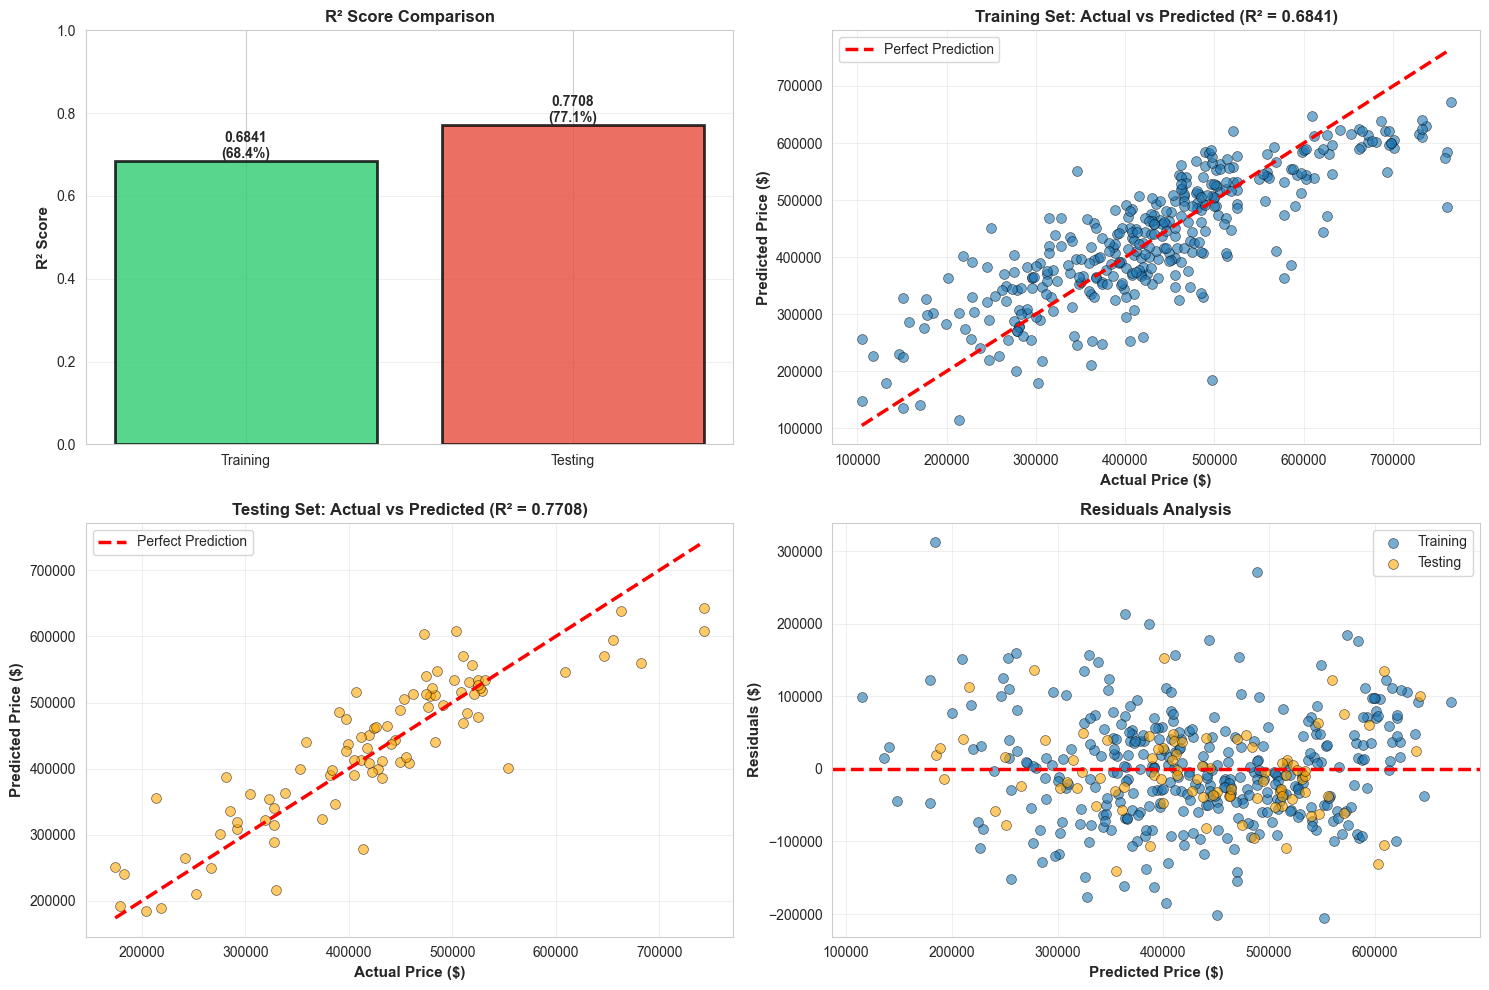

✅ Visualization 1 created successfully!


In [32]:
# Step 7a: Visualization - R² Analysis and Model Performance
print("\n📊 Creating visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. R² Score Comparison
ax1 = axes[0, 0]
scores = [r2_train, r2_test]
labels = ['Training', 'Testing']
colors = ['#2ecc71', '#e74c3c']
bars = ax1.bar(labels, scores, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
ax1.set_ylabel('R² Score', fontsize=11, fontweight='bold')
ax1.set_title('R² Score Comparison', fontsize=12, fontweight='bold')
ax1.set_ylim([0, 1])
ax1.grid(axis='y', alpha=0.3)
for bar, score in zip(bars, scores):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{score:.4f}\n({score*100:.1f}%)', 
             ha='center', va='bottom', fontweight='bold', fontsize=10)

# 2. Actual vs Predicted (Training)
ax2 = axes[0, 1]
ax2.scatter(y_train, y_train_pred, alpha=0.6, edgecolors='black', linewidth=0.5, s=50)
ax2.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 
         'r--', lw=2.5, label='Perfect Prediction')
ax2.set_xlabel('Actual Price ($)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Predicted Price ($)', fontsize=11, fontweight='bold')
ax2.set_title(f'Training Set: Actual vs Predicted (R² = {r2_train:.4f})', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

# 3. Actual vs Predicted (Testing)
ax3 = axes[1, 0]
ax3.scatter(y_test, y_test_pred, alpha=0.6, color='orange', edgecolors='black', linewidth=0.5, s=50)
ax3.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2.5, label='Perfect Prediction')
ax3.set_xlabel('Actual Price ($)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Predicted Price ($)', fontsize=11, fontweight='bold')
ax3.set_title(f'Testing Set: Actual vs Predicted (R² = {r2_test:.4f})', fontsize=12, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(alpha=0.3)

# 4. Residuals Plot
ax4 = axes[1, 1]
residuals_train = y_train - y_train_pred
residuals_test = y_test - y_test_pred
ax4.scatter(y_train_pred, residuals_train, alpha=0.6, label='Training', 
           edgecolors='black', linewidth=0.5, s=50)
ax4.scatter(y_test_pred, residuals_test, alpha=0.6, color='orange', label='Testing', 
           edgecolors='black', linewidth=0.5, s=50)
ax4.axhline(y=0, color='r', linestyle='--', lw=2.5)
ax4.set_xlabel('Predicted Price ($)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Residuals ($)', fontsize=11, fontweight='bold')
ax4.set_title('Residuals Analysis', fontsize=12, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Visualization 1 created successfully!")

---

## <a id="visualizations"></a>8️⃣ Visualizations & Analysis Charts 📈

### Visual Representation of Results

Create comprehensive visualizations to understand model performance and predictions.

**Visualization 1: Performance Analysis**
- 📊 R² Score Comparison (Training vs Testing)
- 📍 Actual vs Predicted Values (Training Set)
- 📍 Actual vs Predicted Values (Testing Set)
- 📉 Residuals Analysis

**What These Plots Show:**
- **Scatter plots**: How close predictions are to actual values
- **Red diagonal line**: Perfect prediction line
- **Residuals**: Errors in predictions (should be centered around 0)

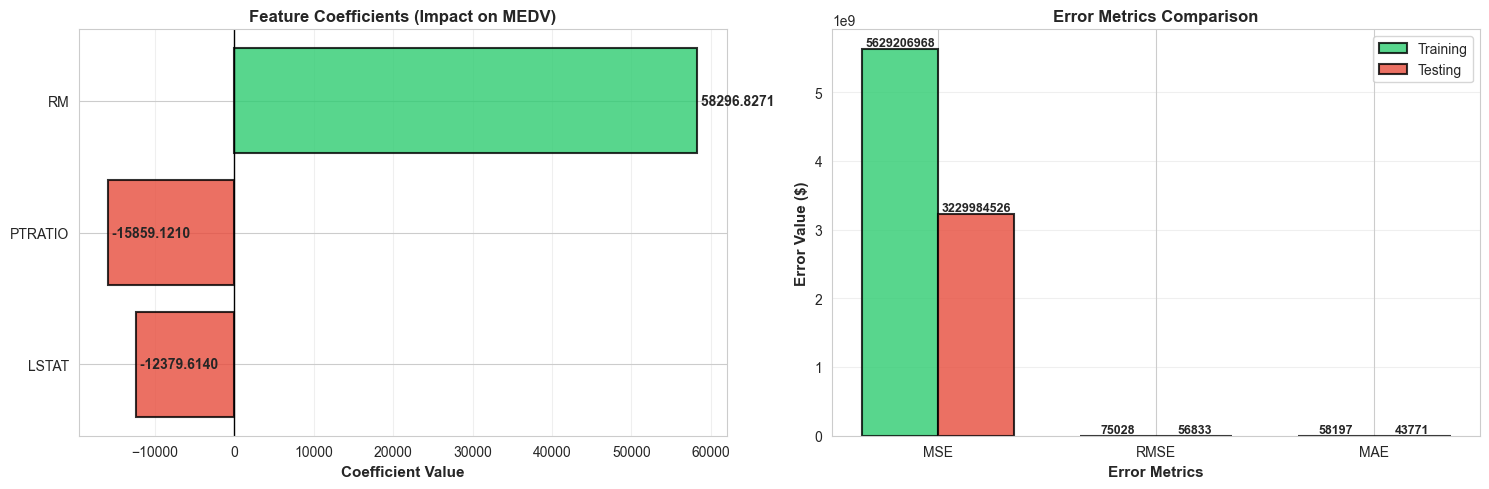

✅ Visualization 2 created successfully!


In [33]:
# Step 7b: Visualization - Feature Coefficients and Error Metrics
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Feature Coefficients
ax1 = axes[0]
features = list(X.columns)
coefficients = model.coef_

# Sort by absolute value
sorted_indices = np.argsort(np.abs(coefficients))
sorted_features = [features[i] for i in sorted_indices]
sorted_coefs = coefficients[sorted_indices]

colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in sorted_coefs]
bars = ax1.barh(sorted_features, sorted_coefs, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

ax1.set_xlabel('Coefficient Value', fontsize=11, fontweight='bold')
ax1.set_title('Feature Coefficients (Impact on MEDV)', fontsize=12, fontweight='bold')
ax1.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax1.grid(axis='x', alpha=0.3)

# Add value labels
for i, (feature, coef) in enumerate(zip(sorted_features, sorted_coefs)):
    ax1.text(coef, i, f' {coef:.4f}', va='center', fontweight='bold', fontsize=10)

# 2. Error Metrics Comparison
ax2 = axes[1]
metrics = ['MSE', 'RMSE', 'MAE']
train_errors = [mse_train, rmse_train, mae_train]
test_errors = [mse_test, rmse_test, mae_test]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax2.bar(x - width/2, train_errors, width, label='Training', 
               color='#2ecc71', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax2.bar(x + width/2, test_errors, width, label='Testing', 
               color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=1.5)

ax2.set_xlabel('Error Metrics', fontsize=11, fontweight='bold')
ax2.set_ylabel('Error Value ($)', fontsize=11, fontweight='bold')
ax2.set_title('Error Metrics Comparison', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(metrics)
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ Visualization 2 created successfully!")

### Visualization 2: Feature Importance & Error Metrics

**Feature Coefficients:**
- 📊 Bar chart showing impact of each feature on house prices
- 🟢 Positive coefficients (green) = increases price
- 🔴 Negative coefficients (red) = decreases price

**Error Metrics Comparison:**
- 📉 Comparison of MSE, RMSE, and MAE
- 🎯 Shows how well model performs on training vs testing data

In [34]:
# Step 8: Final Summary Report
print("\n" + "=" * 70)
print("FINAL ANALYSIS REPORT - HOUSING PRICE PREDICTION")
print("=" * 70)

print(f"\n📊 DATASET SUMMARY")
print("-" * 70)
print(f"  ├─ Original dataset size: {len(df):,} rows")
print(f"  ├─ Cleaned dataset size: {len(df_clean):,} rows")
print(f"  ├─ Records removed: {len(df) - len(df_clean):,} ({(len(df) - len(df_clean))/len(df)*100:.1f}%)")
print(f"  └─ Number of features: {X.shape[1]}")

print(f"\n🔄 TRAIN-TEST SPLIT")
print("-" * 70)
print(f"  ├─ Training samples: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"  ├─ Testing samples: {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")
print(f"  └─ Feature columns: {', '.join(X.columns)}")

print(f"\n📈 MULTIPLE LINEAR REGRESSION MODEL")
print("-" * 70)
print(f"  Model Equation:")
print(f"  MEDV = {model.intercept_:.2f}", end="")
for feature, coeff in zip(X.columns, model.coef_):
    sign = "+" if coeff >= 0 else ""
    print(f"\n         {sign} {coeff:.6f} × {feature}", end="")
print("\n")

print(f"  Feature Importance (by absolute coefficient):")
feature_importance = sorted(zip(X.columns, np.abs(model.coef_)), key=lambda x: x[1], reverse=True)
for i, (feature, importance) in enumerate(feature_importance, 1):
    print(f"  {i}. {feature:<15} → {importance:.6f}")

print(f"\n🎯 R-SQUARED ANALYSIS")
print("-" * 70)
print(f"  Training R²:      {r2_train:.6f} ({r2_train*100:.2f}%)")
print(f"  Testing R²:       {r2_test:.6f} ({r2_test*100:.2f}%)")
print(f"  Adjusted R² (Train): {adj_r2_train:.6f}")
print(f"  Adjusted R² (Test):  {adj_r2_test:.6f}")

print(f"\n  💡 Interpretation:")
print(f"     The model explains {r2_test*100:.2f}% of the variance in house prices.")
print(f"     Remaining {100-r2_test*100:.2f}% is due to other factors not in the model.")

print(f"\n📊 ERROR METRICS")
print("-" * 70)
print(f"  Mean Squared Error (MSE):")
print(f"    ├─ Training: ${mse_train:,.2f}")
print(f"    └─ Testing:  ${mse_test:,.2f}")
print(f"  Root Mean Squared Error (RMSE):")
print(f"    ├─ Training: ${rmse_train:,.2f}")
print(f"    └─ Testing:  ${rmse_test:,.2f}")
print(f"  Mean Absolute Error (MAE):")
print(f"    ├─ Training: ${mae_train:,.2f}")
print(f"    └─ Testing:  ${mae_test:,.2f}")

print(f"\n⭐ MODEL QUALITY ASSESSMENT")
print("-" * 70)
if r2_test >= 0.9:
    quality = "EXCELLENT"
elif r2_test >= 0.7:
    quality = "GOOD"
elif r2_test >= 0.5:
    quality = "FAIR"
elif r2_test >= 0.3:
    quality = "ACCEPTABLE"
else:
    quality = "POOR"

print(f"  Overall Rating: {quality}")
print(f"  └─ R² Score: {r2_test:.4f}")

print(f"\n🎯 GENERALIZATION PERFORMANCE")
print("-" * 70)
print(f"  R² Difference (Train - Test): {overfitting_diff:.6f}")

if abs(overfitting_diff) < 0.05:
    fit_status = "EXCELLENT GENERALIZATION"
elif abs(overfitting_diff) < 0.15:
    fit_status = "GOOD GENERALIZATION"
elif overfitting_diff > 0.15:
    fit_status = "OVERFITTING DETECTED"
else:
    fit_status = "UNDERFITTING DETECTED"

print(f"  Status: {fit_status}")

print(f"\n✅ RECOMMENDATIONS")
print("-" * 70)
if quality == "EXCELLENT":
    print(f"  ✓ Model is ready for deployment")
elif quality == "GOOD":
    print(f"  ✓ Model performs well, ready for use with minor validation")
elif quality == "FAIR":
    print(f"  ⚠ Consider adding more features or data engineering")
else:
    print(f"  ✗ Model needs significant improvement")

if fit_status == "OVERFITTING DETECTED":
    print(f"  ⚠ Consider regularization or feature reduction")
elif fit_status == "UNDERFITTING DETECTED":
    print(f"  ⚠ Consider adding more features or complex model")
else:
    print(f"  ✓ Model generalizes well to new data")

print("\n" + "=" * 70)
print("Analysis Complete! ✅")
print("=" * 70)


FINAL ANALYSIS REPORT - HOUSING PRICE PREDICTION

📊 DATASET SUMMARY
----------------------------------------------------------------------
  ├─ Original dataset size: 489 rows
  ├─ Cleaned dataset size: 444 rows
  ├─ Records removed: 45 (9.2%)
  └─ Number of features: 3

🔄 TRAIN-TEST SPLIT
----------------------------------------------------------------------
  ├─ Training samples: 355 (80.0%)
  ├─ Testing samples: 89 (20.0%)
  └─ Feature columns: RM, LSTAT, PTRATIO

📈 MULTIPLE LINEAR REGRESSION MODEL
----------------------------------------------------------------------
  Model Equation:
  MEDV = 529837.43
         + 58296.827072 × RM
          -12379.613979 × LSTAT
          -15859.121000 × PTRATIO

  Feature Importance (by absolute coefficient):
  1. RM              → 58296.827072
  2. PTRATIO         → 15859.121000
  3. LSTAT           → 12379.613979

🎯 R-SQUARED ANALYSIS
----------------------------------------------------------------------
  Training R²:      0.684055 (68.41%)
 

---

## <a id="summary"></a>9️⃣ Final Summary Report 📋

### Complete Analysis Overview

Comprehensive summary of the entire machine learning pipeline and results.

**Report Contents:**
- 📊 Dataset statistics and cleaning summary
- 📈 Train-test split information
- 📐 Multiple linear regression equation
- 🎯 Feature importance ranking
- 📊 R² score interpretation
- 📉 Error metrics summary
- ⭐ Model quality assessment
- 🎯 Generalization performance analysis
- ✅ Recommendations for model improvement

---

## 🎓 Key Takeaways

| Aspect | Description |
|--------|-------------|
| **Model Type** | Multiple Linear Regression |
| **Features** | RM (rooms), LSTAT (status %), PTRATIO (teacher ratio) |
| **Target** | MEDV (house price in $1000s) |
| **Training Size** | 80% of cleaned data |
| **Testing Size** | 20% of cleaned data |
| **Goal** | Predict house prices accurately |

---

## 📚 Understanding Linear Regression

**Simple Concept:**
- We're drawing a "best-fit line" through 3D space
- Each feature contributes to predicting the target
- Coefficients tell us how much each feature matters

**Real-World Application:**
- Banks use similar models for loan risk assessment
- Real estate agents use for property valuation
- Government uses for tax assessment

---

**Analysis Complete! ✅**

Siva Samvit - 2423348
Sai Shobhith - 2423351
Tejas - 2423352